# 05 · Metabolism

**Panel:** Mitochondria, Pmp70, GRP78/BiP, HSP90, Calreticulin, plus p-S6 and p-AKT

Mitochondria, peroxisomes (Pmp70), the ER stress and chaperone machinery (GRP78,
Calreticulin, HSP90), and the PI3K–mTOR axis that controls whether a cell is in a
growth or a conservation state.

Four of the eighteen conditions are metabolic perturbations — Glucose, LipidMix, MEM AA
and UCL-TRO-1938 — so this panel has a prediction too. It does not come out the way you
would expect, and that is the most interesting thing in the chapter.

The structure is the same as [chapter 03](03_signaling.ipynb); only the panel and the
biology change.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from mcs2026 import analysis, panels, plotting
from mcs2026.config import H5AD_SLIM

plotting.set_style()
pd.set_option("display.width", 140)

THEME = "metabolism"

wells = pd.read_parquet(H5AD_SLIM.with_name("mcs2026_wells.parquet"))
cells = sc.read_h5ad(H5AD_SLIM.with_name("mcs2026_qc.h5ad"))
markers = analysis.panel_markers(cells.var, THEME, wells.columns)
print(f"{len(markers)} markers: {', '.join(markers)}")

7 markers: Mitochondria, Pmp70, GRP78, HSP90, Calreticulin, p-S6, p-AKT


In [2]:
lookup = cells.var[cells.var.marker.isin(markers) & (cells.var.statistic == "mean_intensity")]
lookup[["marker", "round", "channel"]].sort_values("round").reset_index(drop=True)

,marker,round,channel
0,p-S6,15,Cy5
1,Mitochondria,15,FITC
2,Pmp70,17,Cy5
3,GRP78,18,Texas Red
4,HSP90,20,Texas Red
5,p-AKT,24,Cy5
6,Calreticulin,28,FITC


## Effects per condition

In control-well standard deviations, against the DMSO wells of the same timepoint.
PMA is excluded throughout — chapter 02 showed it moves every marker by 4–11 SD, so
leaving it in would make every heatmap a picture of PMA.

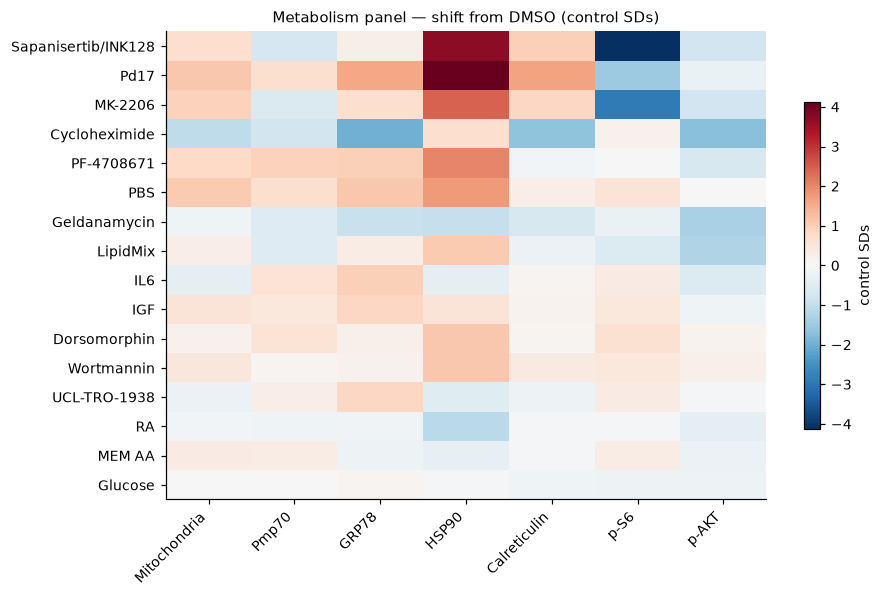

In [3]:
effects = analysis.effect_table(wells, markers, by_timepoint=False)
effects = effects.drop(index=analysis.OUTLIER_CONDITION, errors="ignore")
order = effects.abs().mean(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(8.5, 5.5))
matrix = effects.loc[order]
limit = np.nanpercentile(np.abs(matrix.values), 99)
im = ax.imshow(matrix.values, cmap="RdBu_r", vmin=-limit, vmax=limit, aspect="auto")
ax.set(yticks=range(len(order)), yticklabels=order)
ax.set_xticks(range(len(markers)))
ax.set_xticklabels(markers, rotation=45, ha="right")
ax.set_title(f"{THEME.capitalize()} panel — shift from DMSO (control SDs)")
fig.colorbar(im, ax=ax, shrink=0.7, label="control SDs")
fig.tight_layout()

## Ranked effects

In [4]:
ranked = analysis.rank_effects(wells, markers)
ranked.head(12).round(3)

,condition,marker,shift,n_wells,p,p_floor,abs_shift,at_p_floor
0,Sapanisertib/INK128,p-S6,-5.082,12,0.000,0.0,5.082,False
1,Pd17,HSP90,4.188,12,0.002,0.0,4.188,False
2,Sapanisertib/INK128,HSP90,3.682,12,0.008,0.0,3.682,False
3,MK-2206,p-S6,-2.928,12,0.000,0.0,2.928,False
4,MK-2206,HSP90,2.439,12,0.002,0.0,2.439,False
5,PF-4708671,HSP90,2.005,12,0.083,0.0,2.005,False
6,Cycloheximide,GRP78,-1.985,12,0.002,0.0,1.985,False
7,PBS,HSP90,1.775,12,0.220,0.0,1.775,False
8,Cycloheximide,p-AKT,-1.726,12,0.001,0.0,1.726,False
9,Cycloheximide,Calreticulin,-1.670,12,0.003,0.0,1.670,False


### What the data says

**The metabolic media supplements barely register.** Glucose, LipidMix, MEM AA and
UCL-TRO-1938 are nowhere near the top of the ranking. The conditions that move this
panel most are the *kinase inhibitors*.

That is not a failed experiment; it is a lesson about what the panel measures. These
antibodies report **protein abundance** — how much mitochondrial mass, how much
chaperone. Adding glucose to the medium changes metabolic *flux* within minutes and
need not change how much mitochondrial protein a cell contains 36 hours later. Flux and
abundance are different quantities, and immunofluorescence sees only the second.

**HSP90 rises under kinase inhibition** — Pd17 (+4.2), INK128 (+3.7), MK-2206 (+2.4).
HSP90 is a stress-induced chaperone, so this is a coherent proteostatic stress response
to having a major growth pathway shut off.

**p-S6 falls hardest of anything in the dataset** (INK128, −5.1 control SDs). It sits in
both this panel and the signaling one, which is the whole point of allowing panels to
overlap: mTOR is the hinge between signaling and metabolism, and forcing it into one
box would hide that.

## An embedding of this theme alone

variance explained: [0.522 0.2   0.104 0.066]


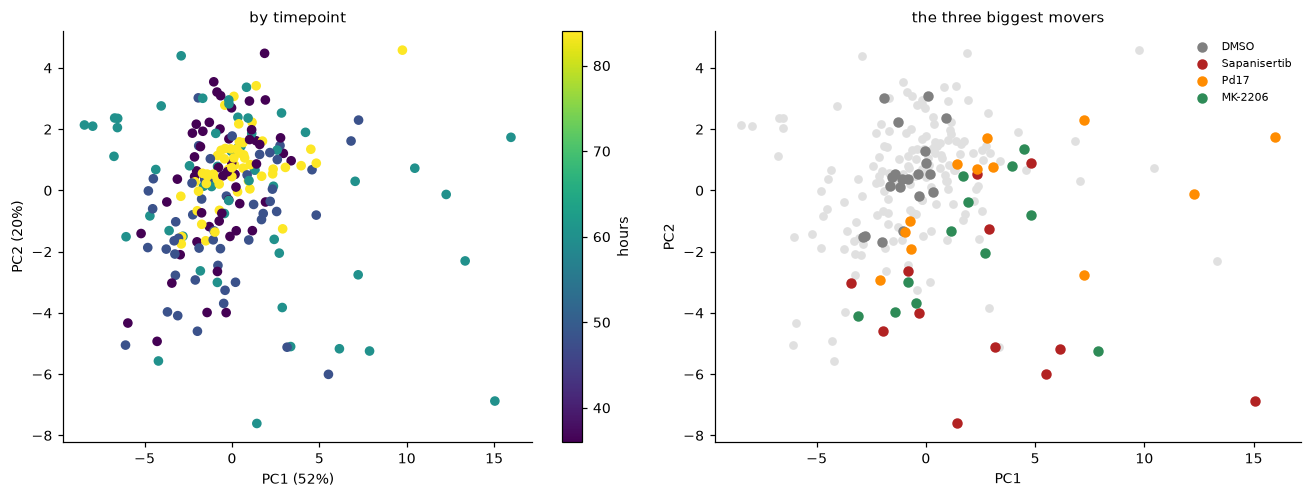

In [5]:
from sklearn.decomposition import PCA

usable = wells[wells.condition != analysis.OUTLIER_CONDITION]
matrix = usable[markers].fillna(0).values
pca = PCA(n_components=4, random_state=0).fit(matrix)
coords = pca.transform(matrix)
print("variance explained:", pca.explained_variance_ratio_[:4].round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
scatter = axes[0].scatter(coords[:, 0], coords[:, 1], c=usable.timepoint.values,
                          cmap="viridis", s=28)
axes[0].set(xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})",
            ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})", title="by timepoint")
fig.colorbar(scatter, ax=axes[0], label="hours")

top = list(effects.abs().mean(axis=1).sort_values(ascending=False).head(3).index)
axes[1].scatter(coords[:, 0], coords[:, 1], c="0.88", s=22)
for condition, colour in zip(["DMSO"] + top, ["0.5", "firebrick", "darkorange", "seagreen"]):
    mask = (usable.condition == condition).values
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=colour, s=34,
                    label=condition.split("/")[0][:22])
axes[1].set(xlabel="PC1", ylabel="PC2", title="the three biggest movers")
axes[1].legend(fontsize=7)
fig.tight_layout()

In [6]:
loadings = pd.DataFrame(pca.components_[:2].T, index=markers, columns=["PC1", "PC2"])
loadings.reindex(loadings.PC1.abs().sort_values(ascending=False).index).round(2)

,PC1,PC2
HSP90,0.89,-0.26
GRP78,0.29,0.38
Mitochondria,0.27,0.17
Calreticulin,0.20,0.30
Pmp70,0.07,0.32
p-S6,-0.03,0.64
p-AKT,0.03,0.39


## Single cells over time

The well means say the average moved. The single-cell distributions say whether every
cell moved a little or a subpopulation moved a lot.

strongest effect in this panel: Sapanisertib/INK128 on p-S6 (-5.08 control SDs)


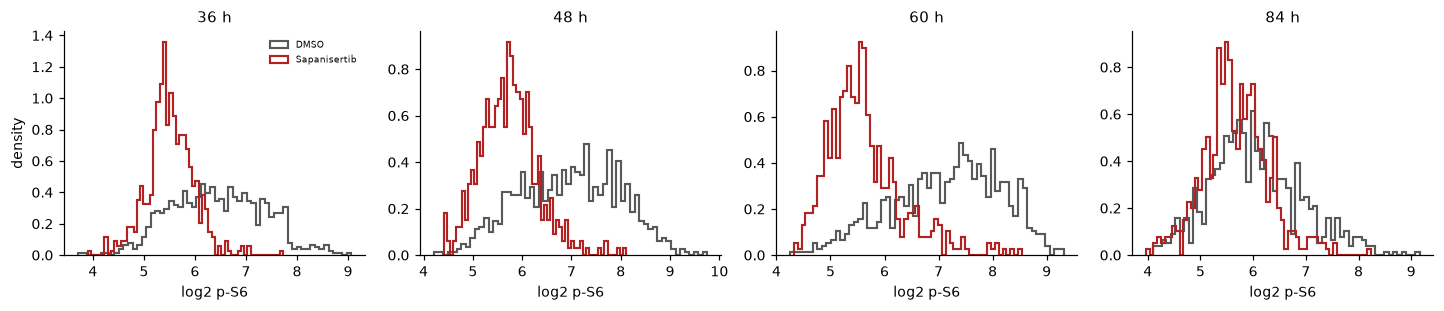

In [7]:
top_pair = ranked.iloc[0]
marker, condition = top_pair["marker"], top_pair["condition"]
print(f"strongest effect in this panel: {condition} on {marker} "
      f"({top_pair['shift']:+.2f} control SDs)")

column = cells.var.index[(cells.var.marker == marker)
                         & (cells.var.statistic == "mean_intensity")
                         & (cells.var.family == "Intensity")][0]
frame = pd.DataFrame({
    "value": np.log2(np.asarray(cells[:, column].X).ravel() + 1),
    "condition": cells.obs.condition.astype(str).values,
    "timepoint": cells.obs.timepoint_h.astype(int).values,
})

fig, axes = plotting.panel_grid(4, ncols=4, size=(3.3, 2.9))
for ax, timepoint in zip(axes, [36, 48, 60, 84]):
    block = frame[frame.timepoint == timepoint]
    for name, colour in [("DMSO", "0.35"), (condition, "firebrick")]:
        values = block.loc[block.condition == name, "value"]
        ax.hist(values, bins=60, histtype="step", density=True,
                color=colour, linewidth=1.4, label=name.split("/")[0][:18])
    ax.set(title=f"{timepoint} h", xlabel=f"log2 {marker}")
    if timepoint == 36:
        ax.set_ylabel("density")
        ax.legend(fontsize=6)
fig.tight_layout()

## One number for the theme

In [8]:
summary = analysis.theme_summary(wells, markers)
summary.drop(index=analysis.OUTLIER_CONDITION, errors="ignore").head(8).round(2)

condition
Sapanisertib/INK128    1.73
Pd17                   1.57
MK-2206                1.32
Cycloheximide          1.15
PF-4708671             0.80
PBS                    0.78
Geldanamycin           0.70
LipidMix               0.61
dtype: float32

In [9]:
summary.to_frame(THEME).to_parquet(H5AD_SLIM.with_name(f"theme_{THEME}.parquet"))
print(f"saved theme summary for {THEME}")

saved theme summary for metabolism


---

**Next:** [06 · Organelles](06_organelles.ipynb).